In [6]:
import onnxruntime as ort
import onnx
from onnx import numpy_helper
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import json

In [7]:
#Windows
# MODEL_PATH = r"E:\le\repos_Git\repos_GB\fold0\model_onnx.onnx"
# JSON_PATH = r"E:\le\repos_Git\repos_GB\fold0\model_onnx.json"

#Linux
MODEL_PATH = r"/media/eqip/T9/le/repos_Git/repos_GB/fold0/model_onnx.onnx"
JSON_PATH = r"/media/eqip/T9/le/repos_Git/repos_GB/fold0/model_onnx.json"

I. Execute model with onnxruntime with random input and anchors

In [8]:
with open(JSON_PATH, "r") as f:
    model_info = json.load(f)

Define input

In [9]:
PATCH_SIZE = tuple(model_info["patch_size"])  # z, y, x
NB_CHANNELS = 1 # input channels
NB_BATCH = model_info["batch_size"]  # batch size
INPUT_SHAPE = (NB_BATCH, NB_CHANNELS) + PATCH_SIZE  # b, c, z, y, x
print("(batches, channels, z, y, x):", INPUT_SHAPE)

input_data = np.random.rand(*INPUT_SHAPE).astype(np.float32)

(batches, channels, z, y, x): (4, 1, 64, 96, 96)


Define anchors

In [10]:
NB_ANCHORS = model_info["nbr_anchors"]
ANCHORS_SHAPE = (NB_BATCH, NB_ANCHORS, 6)  # b, num_anchors, 6 (boxes defined by 6 parameters)
print("(batches, anchors, boxes):", ANCHORS_SHAPE)

anchors_data = np.random.rand(*ANCHORS_SHAPE).astype(np.float32)

(batches, anchors, boxes): (4, 284796, 6)


Define ONNX session and execute model

In [11]:
session = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])

In [12]:
outputs = session.run(None, {
    'images': input_data,
    'anchors': anchors_data
})

In [13]:
#4 batches: 4 batches of boxes, 4 batches of scores, 4 batches of labels
for i, out in enumerate(session.get_outputs()):
    print(f"Sortie {i}: nom={out.name}, shape={outputs[i].shape}")

print()

detections = []
for b in range(NB_BATCH):
    boxes = outputs[b]
    scores = outputs[b + NB_BATCH]
    labels = outputs[b + 2 * NB_BATCH]
    
    batch_results = {
        'boxes': boxes,
        'scores': scores,
        'labels': labels
    }
    detections.append(batch_results)

print("Exemple detection: batch 0, detection 0")
print(detections[0]['boxes'][0])
print(detections[0]['scores'][0])
print(detections[0]['labels'][0])
print()
print("Exemple detection: batch 1, detection 0")
print(detections[1]['boxes'][0])
print(detections[1]['scores'][0])
print(detections[1]['labels'][0])   
print()
print("Exemple detection: batch 0, detection 1")
print(detections[0]['boxes'][1])
print(detections[0]['scores'][1])
print(detections[0]['labels'][1])   


Sortie 0: nom=1073, shape=(59, 6)
Sortie 1: nom=1477, shape=(69, 6)
Sortie 2: nom=1881, shape=(71, 6)
Sortie 3: nom=2285, shape=(43, 6)
Sortie 4: nom=1074, shape=(59,)
Sortie 5: nom=1478, shape=(69,)
Sortie 6: nom=1882, shape=(71,)
Sortie 7: nom=2286, shape=(43,)
Sortie 8: nom=1075, shape=(59,)
Sortie 9: nom=1479, shape=(69,)
Sortie 10: nom=1883, shape=(71,)
Sortie 11: nom=2287, shape=(43,)

Exemple detection: batch 0, detection 0
[0.8914673  0.06357753 1.008671   1.1256726  0.         0.1436454 ]
0.37378085
0

Exemple detection: batch 1, detection 0
[0.07323644 0.53530633 1.0183718  1.0848556  0.2903841  0.43674833]
0.5189825
0

Exemple detection: batch 0, detection 1
[0.47923374 0.24748558 0.9040377  0.96145743 0.         0.58984756]
0.36067432
0


IO basics ok !

II. Compute real anchors

Define function to compute anchors

In [14]:
# Code copied from GB

import numpy as np
from itertools import product
from typing import Sequence, Union, Tuple, List


class AnchorGenerator3DSONNX:
    def __init__(
        self,
        width: Sequence[Union[int, Sequence[int]]],
        height: Sequence[Union[int, Sequence[int]]],
        depth: Sequence[Union[int, Sequence[int]]],
        **kwargs,
    ):
        if not isinstance(width[0], Sequence):
            width = [(w,) for w in width]
        if not isinstance(height[0], Sequence):
            height = [(h,) for h in height]
        if not isinstance(depth[0], Sequence):
            depth = [(d,) for d in depth]
        self.width = width
        self.height = height
        self.depth = depth
        assert len(self.width) == len(self.height) == len(self.depth)
        self.cell_anchors = None
        if kwargs:
            print(f"Discarding anchor generator kwargs {kwargs}")

    def set_cell_anchors(self) -> None:
        if self.cell_anchors is not None:
            return

        cell_anchors = [
            self.generate_anchors(w, h, d)
            for w, h, d in zip(self.width, self.height, self.depth)
        ]
        self.cell_anchors = cell_anchors

    @staticmethod
    def generate_anchors(
        width: Tuple[int],
        height: Tuple[int],
        depth: Tuple[int],
    ) -> np.ndarray:
        all_sizes = (
            np.array(list(product(width, height, depth)), dtype=np.float32) / 2.0
        )
        anchors = np.stack(
            [
                -all_sizes[:, 0],
                -all_sizes[:, 1],
                all_sizes[:, 0],
                all_sizes[:, 1],
                -all_sizes[:, 2],
                all_sizes[:, 2],
            ],
            axis=1,
        )
        return anchors

    def num_anchors_per_location(self) -> List[int]:
        return [
            len(w) * len(h) * len(d)
            for w, h, d in zip(self.width, self.height, self.depth)
        ]

    def grid_anchors(
        self, grid_sizes: Sequence[Sequence[int]], strides: Sequence[Sequence[int]]
    ) -> Tuple[List[np.ndarray], List[int]]:
        assert len(grid_sizes) == len(strides) == len(self.cell_anchors)

        anchors = []
        anchor_per_level = []

        for level, (size, stride, base_anchors) in enumerate(
            zip(grid_sizes, strides, self.cell_anchors)
        ):
            size0, size1, size2 = size
            stride0, stride1, stride2 = stride

            # Create grid shifts
            shifts_x = np.arange(0, size0, dtype=np.float32) * stride0
            shifts_y = np.arange(0, size1, dtype=np.float32) * stride1
            shifts_z = np.arange(0, size2, dtype=np.float32) * stride2

            shift_x, shift_y, shift_z = np.meshgrid(
                shifts_x, shifts_y, shifts_z, indexing="ij"
            )
            shift_x = shift_x.ravel()
            shift_y = shift_y.ravel()
            shift_z = shift_z.ravel()

            shifts = np.stack(
                [shift_x, shift_y, shift_x, shift_y, shift_z, shift_z], axis=1
            )  # shape: (num_positions, 6)

            # Broadcast addition: (num_positions, 1, 6) + (1, num_anchors, 6)
            all_anchors = (
                shifts[:, None, :] + base_anchors[None, :, :]
            )  # (num_positions, num_anchors, 6)
            all_anchors = all_anchors.reshape(-1, 6)  # flatten to (N, 6)

            anchors.append(all_anchors)
            anchor_per_level.append(all_anchors.shape[0])

        return anchors, anchor_per_level

    def forward(
        self, patch_size: np.ndarray, feature_map_size: List[list]
    ) -> List[np.ndarray]:
        """
        Args:
            image_array (np.ndarray): shape (B, C, D, H, W)
            feature_maps (List[np.ndarray]): each with shape (B, C, D', H', W')

        Returns:
            List[np.ndarray]: one [N, 6] anchor array per image in batch
        """
        image_size = patch_size
        # Get grid sizes (D', H', W') for each feature map
        grid_sizes = feature_map_size

        # Compute strides: image_size / feature_map_size
        strides = [
            [int(i / s) for i, s in zip(image_size, fm_size)] for fm_size in grid_sizes
        ]
        self.set_cell_anchors()

        # Assumes cell_anchors are already set
        anchors_per_feature_map, _ = self.grid_anchors(grid_sizes, strides)

        # Duplicate anchors for each image (anchors don't depend on content)
        anchors = np.concatenate(anchors_per_feature_map, axis=0)

        return anchors


Compute the anchors

In [15]:
patch_size = PATCH_SIZE

feature_map_size = model_info["feature_map_size"]

widths = model_info["plan_anchors"]["width"]
heights = model_info["plan_anchors"]["height"]
depths = model_info["plan_anchors"]["depth"]

generator = AnchorGenerator3DSONNX(widths, heights, depths)
anchors = generator.forward(patch_size, feature_map_size)

print("Shape anchors:", anchors.shape)

anchors_batch = np.repeat(anchors[None, :, :], NB_BATCH, axis=0).astype(np.float32)
print("Shape final batch anchors:", anchors_batch.shape)

Shape anchors: (284796, 6)
Shape final batch anchors: (4, 284796, 6)


Plot them

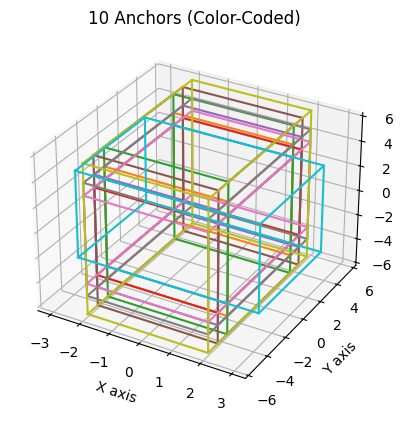

In [16]:
num_anchors_to_plot = 10
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

colors = cm.tab10(np.linspace(0, 1, num_anchors_to_plot))

for i in range(num_anchors_to_plot):
    box = anchors[i]
    color = colors[i]

    x = [box[0], box[2], box[2], box[0], box[0], box[2], box[2], box[0]]
    y = [box[1], box[1], box[3], box[3], box[1], box[1], box[3], box[3]]
    z = [box[4], box[4], box[4], box[4], box[5], box[5], box[5], box[5]]

    # Faces du bas et du haut
    ax.plot3D(x[:4] + [x[0]], y[:4] + [y[0]], z[:4] + [z[0]], color=color)
    ax.plot3D(x[4:] + [x[4]], y[4:] + [y[4]], z[4:] + [z[4]], color=color)

    # Arêtes verticales
    for j in range(4):
        ax.plot3D([x[j], x[j+4]], [y[j], y[j+4]], [z[j], z[j+4]], color=color)

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
plt.title(f'{num_anchors_to_plot} Anchors (Color-Coded)')
plt.show()


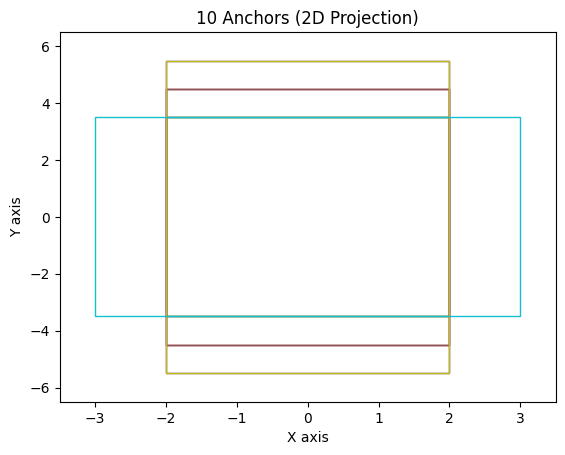

In [17]:
num_anchors_to_plot = 10
anhors_i = [i for i in range(num_anchors_to_plot)]


fig, ax = plt.subplots()
colors = cm.tab10(np.linspace(0, 1, num_anchors_to_plot))
for i in anhors_i:
    box = anchors[i]
    color = colors[i]
    rect = plt.Rectangle(
        (box[0], box[1]),
        box[2] - box[0],
        box[3] - box[1],
        linewidth=1,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
plt.title(f'{num_anchors_to_plot} Anchors (2D Projection)')
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-6.5, 6.5)
#Ploted aspect ratio 1:1
plt.show()

Save them

In [18]:
#Save anchors for onnx model inference as json file
import json
anchors_list = anchors_batch.tolist()
with open(r'/media/eqip/T9/le/repos_Git/repos_GB/fold0/model_onnx_anchors2.json', 'w') as f:
    json.dump(anchors_list, f, indent=4)

In [19]:
#Save as numpy array
np.save(r'/media/eqip/T9/le/repos_Git/repos_GB/fold0/model_onnx_anchors2.npy', anchors_batch)

III. Try on a real image

In [20]:
import SimpleITK as sitk
import pickle as pkl

In [21]:
image_path = "/media/eqip/T9/datasets__storage/SATT/BDD/1_AV_LA/1_AV_LA.nii.gz"
image = sitk.ReadImage(image_path)

In [22]:
#Print dtype of image
print("Image dtype:", image.GetPixelIDTypeAsString())
#Change into float32
image = sitk.Cast(image, sitk.sitkFloat32)
print("Image dtype after cast:", image.GetPixelIDTypeAsString())

Image dtype: 32-bit signed integer
Image dtype after cast: 32-bit float


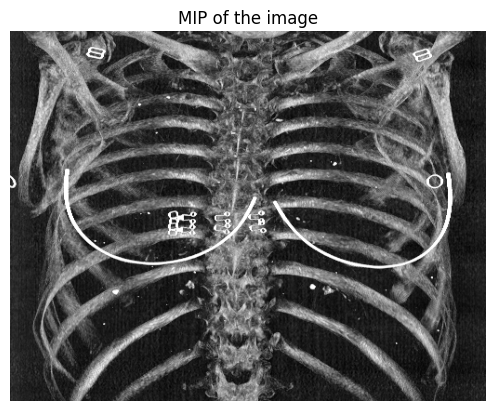

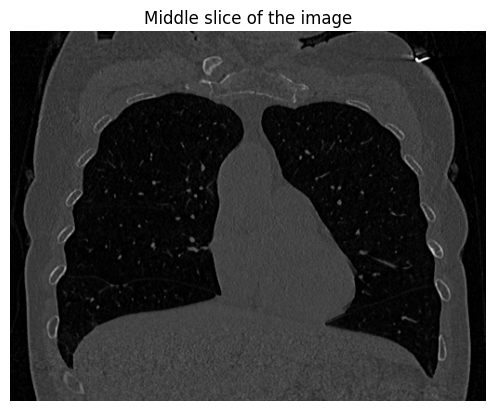

In [23]:
#Plot MIP of the image
image_array = sitk.GetArrayFromImage(image)  # shape (D, H, W)
image_array = np.flip(image_array, axis=0)  # Invert the z-axis for correct orientation
mip = np.max(image_array, axis=1)  # shape (H, W)
midlle_slice = image_array[:, image_array.shape[1] // 3, :]
plt.imshow(mip, cmap='gray')
plt.title("MIP of the image")
plt.axis('off')
plt.show()
plt.imshow(midlle_slice, cmap='gray')
plt.title("Middle slice of the image")
plt.axis('off')
plt.show()

Preprocessing

In [24]:
pkl_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/plan_inference.pkl"
with open(pkl_path, "rb") as f:
    plan_inference = pkl.load(f)
pkl_json_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/plan_inference.json"
with open(pkl_json_path, "w") as f:
    json.dump(plan_inference, f, indent=4) 

Resampling

In [25]:
target_spacing = plan_inference["target_spacing"]
original_spacing = image.GetSpacing()
original_size = image.GetSize()
new_spacing = target_spacing[::-1]  # Reorder to XYZ
new_size = [
    int(np.round(osz * ospc / nspc))
    for osz, ospc, nspc in zip(original_size, original_spacing, new_spacing)
]

print("Target spacing:", target_spacing) #ZYX order
print("Image spacing:", original_spacing) #XYZ order
print("Image size:", original_size) #XYZ order
print("Reordered target spacing:", new_spacing) #XYZ order
print("New size after resampling:", new_size)

Target spacing: [1.25, 0.7617189884185791, 0.7617189884185791]
Image spacing: (0.5546875, 0.5546875, 0.699999988079071)
Image size: (512, 512, 398)
Reordered target spacing: [0.7617189884185791, 0.7617189884185791, 1.25]
New size after resampling: [373, 373, 223]


In [26]:
resampler = sitk.ResampleImageFilter()
resampler.SetOutputSpacing(new_spacing)
resampler.SetSize(new_size)
resampler.SetOutputDirection(image.GetDirection())
resampler.SetOutputOrigin(image.GetOrigin())
resampler.SetInterpolator(sitk.sitkLinear)
resampler.SetDefaultPixelValue(0)
resampler.SetTransform(sitk.Transform())
resampled_image = resampler.Execute(image)

print("New image spacing:", resampled_image.GetSpacing())
print("New image size:", resampled_image.GetSize())

New image spacing: (0.7617189884185791, 0.7617189884185791, 1.25)
New image size: (373, 373, 223)


In [27]:
#Save resampled image to check that it is correct
resampled_image_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/1_AV_LA_resampled.nii.gz"
sitk.WriteImage(resampled_image, resampled_image_path)

Clip and normalize

In [28]:
mean = plan_inference["dataset_properties"]["intensity_properties"][0]["mean"]
std = plan_inference["dataset_properties"]["intensity_properties"][0]["std"]
min_val = plan_inference["dataset_properties"]["intensity_properties"][0]["min"]
max_val = plan_inference["dataset_properties"]["intensity_properties"][0]["max"]
median = plan_inference["dataset_properties"]["intensity_properties"][0]["median"]
percentile_99_5 = plan_inference["dataset_properties"]["intensity_properties"][0]["percentile_99_5"]
percentile_00_5 = plan_inference["dataset_properties"]["intensity_properties"][0]["percentile_00_5"]

print("mean:", mean)
print("std:", std)
print("min:", min_val)
print("max:", max_val)
print("median:", median)
print("percentile_99_5", percentile_99_5)
print("percentile_00_5", percentile_00_5)

mean: 38.51783752441406
std: 170.19082641601562
min: -3047.0
max: 15936.0
median: 40.0
percentile_99_5 817.0
percentile_00_5 -891.0


In [29]:
clamper = sitk.ClampImageFilter()
clamper.SetLowerBound(percentile_00_5)
clamper.SetUpperBound(percentile_99_5)
clamped_image = clamper.Execute(resampled_image)

print("Clamped image min:", sitk.GetArrayFromImage(clamped_image).min())
print("Clamped image max:", sitk.GetArrayFromImage(clamped_image).max())
print("Original image min:", sitk.GetArrayFromImage(image).min())
print("Original image max:", sitk.GetArrayFromImage(image).max())
print("Resampled image min:", sitk.GetArrayFromImage(resampled_image).min())
print("Resampled image max:", sitk.GetArrayFromImage(resampled_image).max())

Clamped image min: -891.0
Clamped image max: 817.0
Original image min: -1024.0
Original image max: 3071.0
Resampled image min: -1024.0
Resampled image max: 3071.0


In [30]:
#Save clamped image to check that it is correct
clamped_image_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/1_AV_LA_clamped.nii.gz"
sitk.WriteImage(clamped_image, clamped_image_path)

Mean and std of the foreground

In [31]:
zscorer = sitk.ShiftScaleImageFilter()
zscorer.SetShift(-mean)
zscorer.SetScale(1.0 / std)
normalized_image = zscorer.Execute(clamped_image)

print("Normalized image min:", sitk.GetArrayFromImage(normalized_image).min())
print("Normalized image max:", sitk.GetArrayFromImage(normalized_image).max())
print("Normalized image mean:", sitk.GetArrayFromImage(normalized_image).mean())
print("Normalized image std:", sitk.GetArrayFromImage(normalized_image).std())
print("Clamped image mean:", sitk.GetArrayFromImage(clamped_image).mean())
print("Clamped image std:", sitk.GetArrayFromImage(clamped_image).std())

Normalized image min: -5.4616213
Normalized image max: 4.5741725
Normalized image mean: -3.0777323
Normalized image std: 2.7523644
Clamped image mean: -485.28342
Clamped image std: 468.4272


In [32]:
print(normalized_image.GetSpacing())
print(normalized_image.GetSize())

(0.7617189884185791, 0.7617189884185791, 1.25)
(373, 373, 223)


In [33]:
#Save normalized image to check that it is correct
normalized_image_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/1_AV_LA_normalized.nii.gz"
sitk.WriteImage(normalized_image, normalized_image_path)

Crop to create a unique patch

In [34]:
#Crop to patch size
crop_lower = [40, 80, 40]
cropper = sitk.CropImageFilter()
cropper.SetLowerBoundaryCropSize(crop_lower)
cropper.SetUpperBoundaryCropSize([
    normalized_image.GetSize()[0] - PATCH_SIZE[2] - crop_lower[0],
    normalized_image.GetSize()[1] - PATCH_SIZE[1] - crop_lower[1],
    normalized_image.GetSize()[2] - PATCH_SIZE[0] - crop_lower[2]
])
cropped_image = cropper.Execute(normalized_image)

print("Cropped image size:", cropped_image.GetSize())
print("Cropped image spacing:", cropped_image.GetSpacing())

Cropped image size: (96, 96, 64)
Cropped image spacing: (0.7617189884185791, 0.7617189884185791, 1.25)


In [35]:
#Save cropped image to check that it is correct
cropped_image_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/1_AV_LA_cropped.nii.gz"
sitk.WriteImage(cropped_image, cropped_image_path)

Execute model

In [36]:
array = sitk.GetArrayFromImage(cropped_image)
print("Cropped image array shape:", array.shape)
print("Cropped image dtype:", array.dtype)
print("Patch size:", PATCH_SIZE)

Cropped image array shape: (64, 96, 96)
Cropped image dtype: float32
Patch size: (64, 96, 96)


In [37]:
#Create a (4, 1, 64, 96, 96) array for onnx model inference by duplicating the cropped image 4 times and adding a channel dimension
input_array = np.expand_dims(array, axis=0)  # shape (1, D, H, W)
input_array = np.repeat(input_array, NB_BATCH, axis=0)
input_array = np.expand_dims(input_array, axis=1)  # shape (B, 1, D, H, W)
print("Input array shape for ONNX model:", input_array.shape)

Input array shape for ONNX model: (4, 1, 64, 96, 96)


In [38]:
session2 = ort.InferenceSession(MODEL_PATH, providers=['CPUExecutionProvider'])
outputs_pred = session2.run(None, {
    'images': input_array,
    'anchors': anchors_batch
})

In [39]:
#4 batches: 4 batches of boxes, 4 batches of scores, 4 batches of labels
for i, out in enumerate(session.get_outputs()):
    print(f"Sortie {i}: nom={out.name}, shape={outputs_pred[i].shape}")

print()

detections = []
for b in range(NB_BATCH):
    boxes = outputs_pred[b]
    scores = outputs_pred[b + NB_BATCH]
    labels = outputs_pred[b + 2 * NB_BATCH]
    
    batch_results = {
        'boxes': boxes,
        'scores': scores,
        'labels': labels
    }
    detections.append(batch_results)

print("Exemple detection: batch 0, detection 0")
print(detections[0]['boxes'][0])
print(detections[0]['scores'][0])
print(detections[0]['labels'][0])
print()
print("Exemple detection: batch 1, detection 0")
print(detections[1]['boxes'][0])
print(detections[1]['scores'][0])
print(detections[1]['labels'][0])   
print()
print("Exemple detection: batch 0, detection 1")
print(detections[0]['boxes'][1])
print(detections[0]['scores'][1])
print(detections[0]['labels'][1])   


Sortie 0: nom=1073, shape=(500, 6)
Sortie 1: nom=1477, shape=(500, 6)
Sortie 2: nom=1881, shape=(500, 6)
Sortie 3: nom=2285, shape=(500, 6)
Sortie 4: nom=1074, shape=(500,)
Sortie 5: nom=1478, shape=(500,)
Sortie 6: nom=1882, shape=(500,)
Sortie 7: nom=2286, shape=(500,)
Sortie 8: nom=1075, shape=(500,)
Sortie 9: nom=1479, shape=(500,)
Sortie 10: nom=1883, shape=(500,)
Sortie 11: nom=2287, shape=(500,)

Exemple detection: batch 0, detection 0
[22.939037 18.302189 28.024021 26.548878 38.302372 46.626614]
0.9887092
0

Exemple detection: batch 1, detection 0
[22.939037 18.302189 28.024021 26.548878 38.302372 46.626614]
0.9887092
0

Exemple detection: batch 0, detection 1
[22.94127  18.297495 28.009302 26.556253 38.31224  46.615692]
0.98849505
0


Investigation

500?

In [40]:
for thresh in [0.0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.98, 0.985, 1.0]:
    keep = outputs_pred[4] > thresh   # scores batch 0
    print(thresh, keep.sum())

0.0 500
0.01 500
0.05 500
0.1 500
0.2 500
0.3 343
0.5 178
0.7 122
0.9 84
0.98 12
0.985 3
1.0 0


In [41]:
model = onnx.load(MODEL_PATH)

print("\n=== Nodes TopK / NMS ===")

for node in model.graph.node:
    if node.op_type in ["TopK", "NonMaxSuppression"]:
        print(f"\nNode: {node.name}")
        print(f"Type: {node.op_type}")
        print("Inputs:", node.input)
        print("Outputs:", node.output)

print()

target_outputs = {
    "/Constant_171_output_0",
    "/Constant_297_output_0",
    "/Constant_423_output_0",
    "/Constant_549_output_0",
}

print("----------")

for node in model.graph.node:
    if node.op_type == "Constant" and node.output[0] in target_outputs:
        print(f"\nNode: {node.name}")
        print(f"Output: {node.output[0]}")
        for attr in node.attribute:
            if attr.name == "value":
                arr = numpy_helper.to_array(attr.t)
                print("Valeur:", arr, "shape =", arr.shape)


=== Nodes TopK / NMS ===

Node: /TopK
Type: TopK
Inputs: ['/Reshape_10_output_0', '/Constant_171_output_0']
Outputs: ['/TopK_output_0', '/TopK_output_1']

Node: /TopK_1
Type: TopK
Inputs: ['/Reshape_17_output_0', '/Constant_297_output_0']
Outputs: ['/TopK_1_output_0', '/TopK_1_output_1']

Node: /TopK_2
Type: TopK
Inputs: ['/Reshape_24_output_0', '/Constant_423_output_0']
Outputs: ['/TopK_2_output_0', '/TopK_2_output_1']

Node: /TopK_3
Type: TopK
Inputs: ['/Reshape_31_output_0', '/Constant_549_output_0']
Outputs: ['/TopK_3_output_0', '/TopK_3_output_1']

----------

Node: /Constant_171
Output: /Constant_171_output_0
Valeur: [500] shape = (1,)

Node: /Constant_297
Output: /Constant_297_output_0
Valeur: [500] shape = (1,)

Node: /Constant_423
Output: /Constant_423_output_0
Valeur: [500] shape = (1,)

Node: /Constant_549
Output: /Constant_549_output_0
Valeur: [500] shape = (1,)


In [42]:
print(any(node.op_type == "TopK" for node in model.graph.node))
print(any(node.op_type == "NonMaxSuppression" for node in model.graph.node))

True
False


Formalize to check boxes

In [67]:
#Take the box with the highest score in batch 0

n = 100

detection = detections[0]

best_box = detection['boxes'][n]
best_score = detection['scores'][n]
best_label = detection['labels'][n]

print("Best box (batch 0, detection {}):".format(n), best_box)
print("Best score (batch 0, detection {}):".format(n), best_score)
print("Best label (batch 0, detection {}):".format(n), best_label)

#Create a 3D array of zeros with the same shape as the input patch, and draw the best box on it
box_image = np.zeros(PATCH_SIZE, dtype=np.float32)
x_min, y_min, x_max, y_max, z_min, z_max = best_box.astype(int)
box_image[x_min:x_max, y_min:y_max, z_min:z_max] = 1.0

#Create a sitk image from the box image and save it to check that it is correct
box_sitk = sitk.GetImageFromArray(box_image)
box_sitk.SetSpacing(cropped_image.GetSpacing())
box_sitk.SetOrigin(cropped_image.GetOrigin())
box_sitk.SetDirection(cropped_image.GetDirection())
box_sitk_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/best_box_{}.nii.gz".format(n)
sitk.WriteImage(box_sitk, box_sitk_path)

Best box (batch 0, detection 100): [26.91287  42.39748  34.187996 57.31106  34.08973  50.327408]
Best score (batch 0, detection 100): 0.80836785
Best label (batch 0, detection 100): 0


Postprocessing

Score

In [84]:
model_score_thresh = plan_inference["inference_plan"]["model_score_thresh"]
model_score_thresh = 0.5

In [85]:
#Delete all boxes with score < model_score_thresh and print how many boxes are kept
boxes = detection['boxes']
scores = detection['scores']
keep = scores > model_score_thresh

print("Number of boxes before filtering:", len(boxes))
print("Number of boxes after filtering with threshold {}: {}".format(model_score_thresh, keep.sum()))

filtered_boxes = boxes[keep]
filtered_scores = scores[keep]
filtered_labels = labels[keep]
    
detection_filtered = {
    'boxes': filtered_boxes,
    'scores': filtered_scores,
    'labels': filtered_labels
}

Number of boxes before filtering: 500
Number of boxes after filtering with threshold 0.5: 178


In [86]:
print(len(detection_filtered['boxes']))
print(len(detection['scores']))

178
500


Size

In [87]:
target_spacing

[1.25, 0.7617189884185791, 0.7617189884185791]

In [88]:
remove_small_boxes = plan_inference["inference_plan"]["remove_small_boxes"]
remove_small_boxes_mm  = 2.0

In [89]:
#Delete all boxes with at list an axis smaller than remove_small_boxes and print how many boxes are kept
keep = np.zeros(len(detection_filtered['boxes']), dtype=bool)

min_size_mm = remove_small_boxes_mm

for i, box in enumerate(detection_filtered['boxes']):
    x_min, y_min, x_max, y_max, z_min, z_max = box

    dx_mm = (x_max - x_min) * cropped_image.GetSpacing()[0]
    dy_mm = (y_max - y_min) * cropped_image.GetSpacing()[1]
    dz_mm = (z_max - z_min) * cropped_image.GetSpacing()[2]


    if (dx_mm >= min_size_mm) and (dy_mm >= min_size_mm) and (dz_mm >= min_size_mm):
        keep[i] = True
        
        
print("Number of boxes before removing small boxes:", len(detection_filtered['boxes']))
print("Number of boxes after removing small boxes with threshold {}: {}".format(remove_small_boxes_mm, keep.sum()))

filtered_boxes2 = detection_filtered['boxes'][keep]
filtered_scores2 = detection_filtered['scores'][keep]
filtered_labels2 = detection_filtered['labels'][keep]

detection_filtered2 = {
    'boxes': filtered_boxes2,
    'scores': filtered_scores2,
    'labels': filtered_labels2
}

Number of boxes before removing small boxes: 178
Number of boxes after removing small boxes with threshold 2.0: 178


In [90]:
print(len(detection_filtered2['boxes']))
print(len(detection['scores']))

178
500


NMS

In [91]:
#CPU from nndet repo
from nndet.core.boxes import nms
import torch

In [92]:
filtered_boxes2_tensor = torch.from_numpy(filtered_boxes2)
filtered_scores2_tensor = torch.from_numpy(filtered_scores2)
print("GPU:", filtered_boxes2_tensor.is_cuda, filtered_scores2_tensor.is_cuda)

GPU: False False


In [93]:
nms_iou = plan_inference["inference_plan"]["model_iou"]

In [94]:
nms_results = nms(filtered_boxes2_tensor, filtered_scores2_tensor, iou_threshold=nms_iou)

In [95]:
nms_results

tensor([ 0, 57])

In [102]:
#Create a unified nifti mask with the same shape as the input patch, and draw all the boxes kept after NMS on it
nms_mask = np.zeros(PATCH_SIZE, dtype=np.float32)
for idx in nms_results:
    box = filtered_boxes2[idx]
    x_min, y_min, x_max, y_max, z_min, z_max = box.astype(int)
    nms_mask[x_min:x_max, y_min:y_max, z_min:z_max] = 1.0
nms_mask_sitk = sitk.GetImageFromArray(nms_mask)
nms_mask_sitk.SetSpacing(cropped_image.GetSpacing())
nms_mask_sitk.SetOrigin(cropped_image.GetOrigin())
nms_mask_sitk.SetDirection(cropped_image.GetDirection())
nms_mask_sitk = sitk.Cast(nms_mask_sitk, sitk.sitkUInt8)

nms_mask_connected = sitk.ConnectedComponent(nms_mask_sitk)

nms_mask_path = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/nms_mask.nii.gz"
nms_mask_path_connected = "/media/eqip/T9/le/repos_Git/repos_GB/fold0/nms_mask_connected.nii.gz"

sitk.WriteImage(nms_mask_sitk, nms_mask_path) 
sitk.WriteImage(nms_mask_connected, nms_mask_path_connected)